# Feature tracking

Julia ImageFeatures provides access to well-known feature tracking algorithms including BRIEF, ORB, and BRISK. There appear to be lots of options for using different methods to calculate key points and adjust the size of windows used. Here I look at some cases with pretty clear floes and detectable motion. I got reasonably good vectors fairly quickly with these.

Some notes:
* The vectors with the default fast corners algorithm are denser in regions without very many ice floes.
* I have to set a threshold of the maximum displacement, otherwise I get really noisy results
* There are tons of parameters to choose from, which makes it a challenge to see where to start, but suggests that we could adapt some methods to work better.
* The vectors are mostly around edges, which means that getting the floe shapes would actually help a lot.

In [1]:
using Pkg
Pkg.activate("calval")
Pkg.update(; name="IceFloeTracker", rev="main")
using IceFloeTracker
using Images
using Random
using DataFrames
using Plots
using StatsBase

using ImageFeatures

  Activating project at `~/Documents/research/calval_tgrs/notebooks/calval`
    Updating registry at `~/.julia/registries/General.toml`
    Updating git-repo `https://github.com/WilhelmusLab/IceFloeTracker.jl.git`
    Updating `~/Documents/research/calval_tgrs/notebooks/calval/Project.toml`
  [04643c7a] ~ IceFloeTracker v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main` ⇒ v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main`
    Updating `~/Documents/research/calval_tgrs/notebooks/calval/Manifest.toml`
  [04643c7a] ~ IceFloeTracker v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main` ⇒ v1.0.0 `https://github.com/WilhelmusLab/IceFloeTracker.jl.git#main`
Precompiling packages...
  12345.5 ms  ✓ IceFloeTracker
  1 dependency successfully precompiled in 15 seconds. 517 already precompiled.
        Info We haven't cleaned this depot up for a bit, running Pkg.gc()...
      Active manifest files: 9 found
      Active artifact files: 216 found
    

LoadError: ArgumentError: Package ImageFeatures not found in current path.
- Run `import Pkg; Pkg.add("ImageFeatures")` to install the ImageFeatures package.

In [2]:
dataset = Watkins2026Dataset(ref="v0.2") # [6, 13, 61, 25, 121, 166]
# Generate full list so I can separate training and testing
case = filter(f -> f.case_number in [6, 11, 63, 111, 138, 121], dataset)

Dataset(GitHubLoader("https://github.com/danielmwatkins/ice-floe-validation-dataset/", "v0.2", "/tmp/Watkins2026"), 12×26 DataFrame
 Row │        case_number  region         satellite  start_date  pass_time     ⋯
     │ Int64  Int64        String         String     Dates.Date  DateTime      ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │    10            6  baffin_bay     terra      2022-05-30  2022-05-30T16 ⋯
   2 │    11            6  baffin_bay     aqua       2022-05-30  2022-05-30T15
   3 │    20           11  baffin_bay     aqua       2011-07-02  2011-07-02T16
   4 │    21           11  baffin_bay     terra      2011-07-02  2011-07-02T17
   5 │   124           63  beaufort_sea   aqua       2007-07-11  2007-07-11T19 ⋯
   6 │   125           63  beaufort_sea   terra      2007-07-11  2007-07-11T20
   7 │   220          111  greenland_sea  aqua       2012-06-23  2012-06-23T11
   8 │   221          111  greenland_sea  terra      2012-06-23  201

In [3]:
abstract type IceFloePreprocessingAlgorithm end

@kwdef struct Preprocess <: IceFloePreprocessingAlgorithm
    diffusion_algorithm = PeronaMalikDiffusion(λ=0.1, K=0.1, niters=5, g="exponential")
    adapthisteq_params = (nbins=256, rblocks=8, cblocks=8, clip=0.99) # rblocks/cblocks not used yet -- add with CLAHE.jl
    unsharp_mask_params = (radius=50, amount=0.2, threshold=0.01)
end

function (p::Preprocess)(
    truecolor_image::AbstractArray{<:Union{AbstractRGB,TransparentRGB}}, 
    landmask,
    cloud_mask,
    tiles
)
    # Cast to grayscale first to save compute time
    proc_img = Gray.(truecolor_image)
    apply_landmask!(proc_img, landmask .|| cloud_mask)

    # Diffusion and sharpening
    for tile in tiles
        proc_img[tile...] .= nonlinear_diffusion(proc_img[tile...], p.diffusion_algorithm)
    end
    
    adjust_histogram!(proc_img,
        ContrastLimitedAdaptiveHistogramEqualization(
            nbins=p.adapthisteq_params.nbins,
            rblocks=p.adapthisteq_params.rblocks,
            cblocks=p.adapthisteq_params.cblocks,
            clip=p.adapthisteq_params.clip)
    )

    for tile in tiles
        proc_img[tile...] .= unsharp_mask(proc_img[tile...],
                p.unsharp_mask_params.radius,
                p.unsharp_mask_params.amount,
                p.unsharp_mask_params.threshold)
    end

            
    apply_landmask!(proc_img, landmask .|| cloud_mask)
    
    return proc_img
end

function se_disk(r)
    se = [sum(abs.(c.I .- (r + 1)) .^ 2) for c in CartesianIndices((2*r + 1, 2*r + 1))]
    return sqrt.(se) .<= r
end

se_disk (generic function with 1 method)

In [4]:
truecolor_image = modis_truecolor.(case)
falsecolor_image = modis_falsecolor.(case)
land_mask = modis_landmask.(case)
land_mask = BitMatrix[Gray.(r) .> 0 for r in land_mask]
cloud_mask = Watkins2025CloudMask().(falsecolor_image)
coastal_buffer = create_coastal_buffer_mask.(land_mask, [strel_box((51,51))])
tiles = get_tiles(truecolor_image[1], 400) # Cal-val paper may or may not include the tiling portion...
proc_gray = Preprocess().(truecolor_image, cloud_mask, land_mask, [tiles]);
prelim_ice = IceDetectionBrightnessPeaksMODIS134(band_1_min=0.3)

# Mask images before k-means, preliminary ice mask application
tc_masked = apply_landmask.(truecolor_image, cloud_mask)
tc_masked .= apply_landmask.(tc_masked, land_mask)
fc_masked = apply_landmask.(falsecolor_image, cloud_mask)
fc_masked .= apply_landmask.(fc_masked, coastal_buffer)
prelim_ice_mask = prelim_ice.(tc_masked)

# Apply the sea ice mask to the preprocessed image
proc_gray_masked = [apply_landmask(proc_gray[idx], .!prelim_ice_mask[idx]) for idx in range(1, length(proc_gray))];

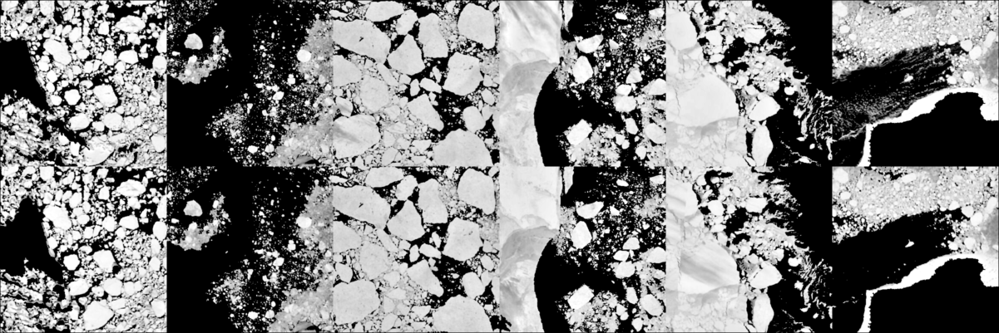

In [5]:
mosaicview(proc_gray_masked, nrow=2)

In [163]:
img1 = proc_gray[3]
img2 = proc_gray[4]
keypoints_1 = Keypoints(fastcorners(img1, 12, 0.1))
keypoints_2 = Keypoints(fastcorners(img2, 12, 0.1));

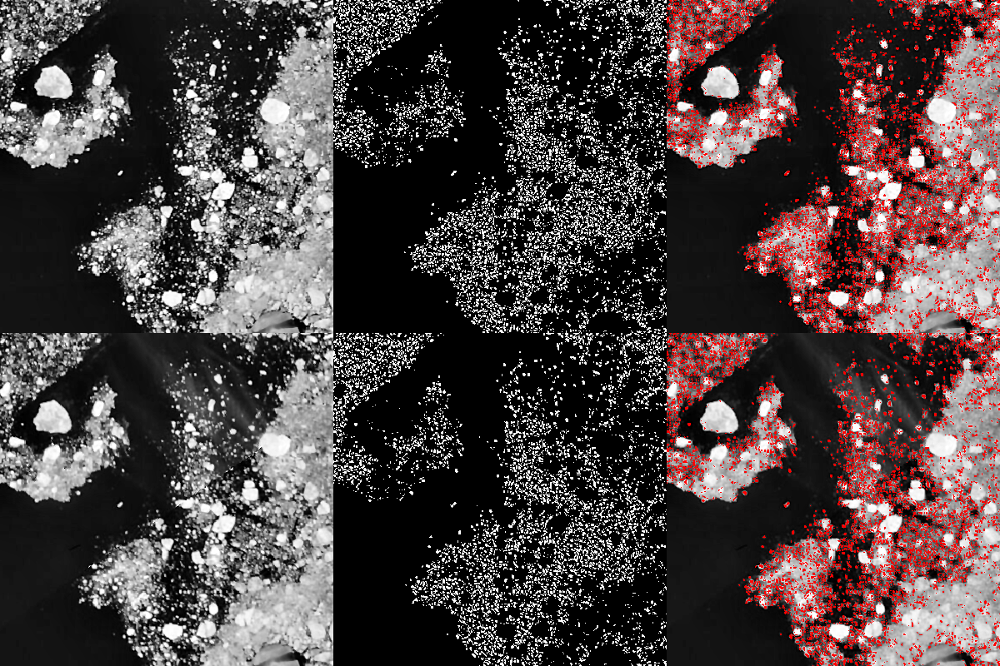

In [166]:
overlay = RGB.(img1)
c1 = fastcorners(img1, 12, 0.1)
overlay[c1 .> 0] .= RGB(1, 0, 0)

overlay2 = RGB.(img2)
c2 = fastcorners(img2, 12, 0.1)
overlay2[c2 .> 0] .= RGB(1, 0, 0)

mosaicview(
    mosaicview(img1, Gray.(c1), overlay, nrow=1),
    mosaicview(img2, Gray.(c2), overlay2, nrow=1))

In [168]:
brief_params = BRIEF(size = 256, window = 10, seed = 123);

In [172]:
?BRIEF

search: BRIEF BRISK



```julia
brief_params = BRIEF([size = 128], [window = 9], [sigma = 2 ^ 0.5], [sampling_type = gaussian], [seed = 123])
```

| Argument          | Type     | Description                                                                                                                   |
|:----------------- |:-------- |:----------------------------------------------------------------------------------------------------------------------------- |
| **size**          | Int      | Size of the descriptor                                                                                                        |
| **window**        | Int      | Size of sampling window                                                                                                       |
| **sigma**         | Float64  | Value of sigma used for initial gaussian smoothing of image                                                                   |
| **sampling_type** | Function | Type of sampling used for building the descriptor (See [BRIEF Sampling Patterns](#brief-sampling-patterns))                   |
| **seed**          | Int      | Random seed used for generating the sampling pairs. For matching two descriptors, the seed used to build both should be same. |


In [169]:
desc_1, ret_keypoints_1 = create_descriptor(img1, keypoints_1, brief_params)
desc_2, ret_keypoints_2 = create_descriptor(img2, keypoints_2, brief_params);

In [170]:
# Lots of vectors, unlikely to get matches in most. Could filter by proximity to floes
@time begin
    matches = match_keypoints(ret_keypoints_1, ret_keypoints_2, desc_1, desc_2, 0.1)
end
nothing

 21.764868 seconds (1.36 G allocations: 63.592 GiB, 27.52% gc time)


In [173]:
# Turn the cartesian indices into a vector
m1 = first.(matches) .|> r -> r.I
m2 = last.(matches) .|> r -> r.I
x = first.(m1)
y = last.(m1)
u = first.(m2) .- first.(m1)
v = last.(m2) .- last.(m1);
idx = (sqrt.(u .^ 2 .+ v .^ 2) .< 5);

In [174]:
sum(idx)

8544

In [175]:
using CairoMakie

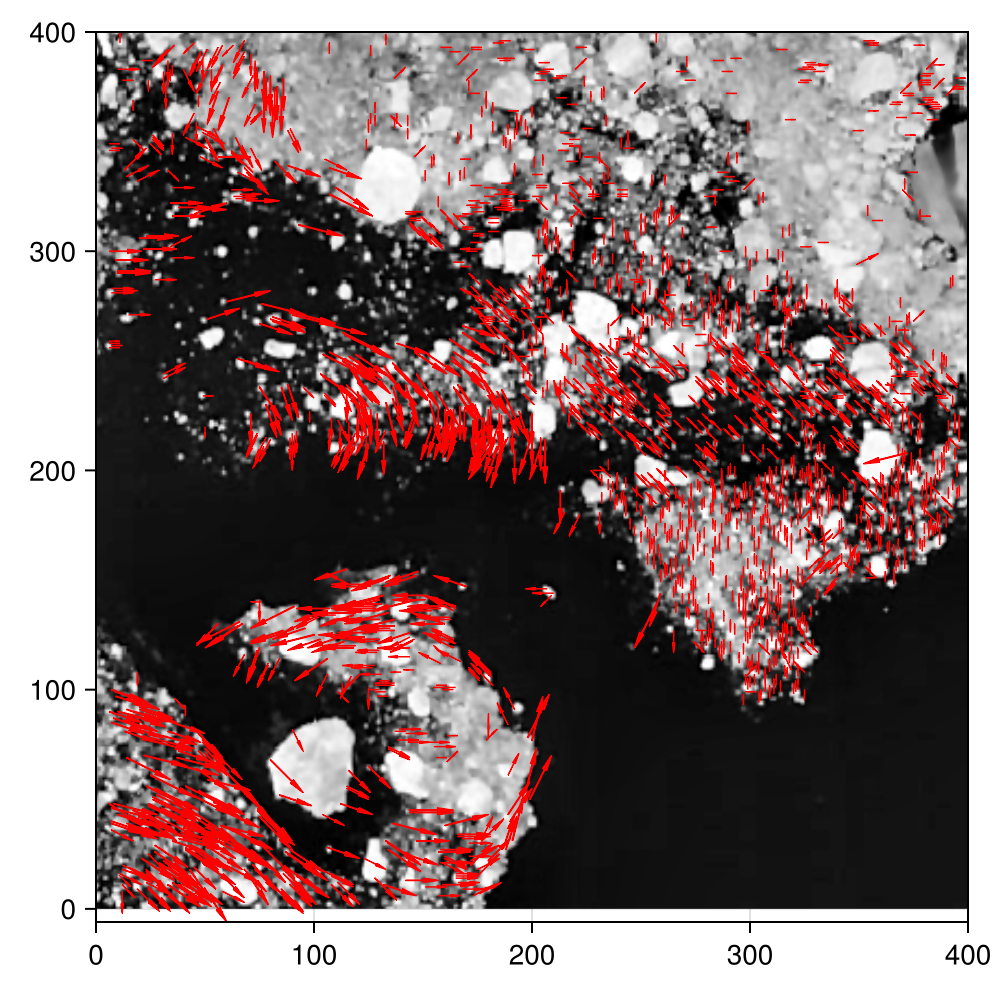

In [176]:
f = Figure(size=(500,500))
ax = CairoMakie.Axis(f[1,1])
image!(ax, img1)
arrows2d!(x[idx][1:3:end], y[idx][1:3:end],
    u[idx][1:3:end], v[idx][1:3:end], color=:red, shaftwidth=1, tipwidth=3, lengthscale=5)
f

After filtering out the very large vectors, the results actually look really compelling. We've got the rotational motion I would expect. There's a good chance, I think, that this could be combined with the floe shapes to get a two-way method for confirming motion. This is with the BRIEF method. We also have access to ORB and BRISK. 

In [109]:
brisk_params = BRISK()
features_1 = Features(fastcorners(img1, 12, 0.1)) # Difference here is "Features" first instead of "Keypoints"
features_2 = Features(fastcorners(img2, 12, 0.1))
desc_1, ret_features_1 = create_descriptor(img1, features_1, brisk_params)
desc_2, ret_features_2 = create_descriptor(img2, features_2, brisk_params);

In [110]:
@time begin
    matches = match_keypoints(Keypoints(ret_features_1), Keypoints(ret_features_2), desc_1, desc_2, 0.1);
end
nothing

 18.848122 seconds (1.14 G allocations: 63.299 GiB, 30.93% gc time)


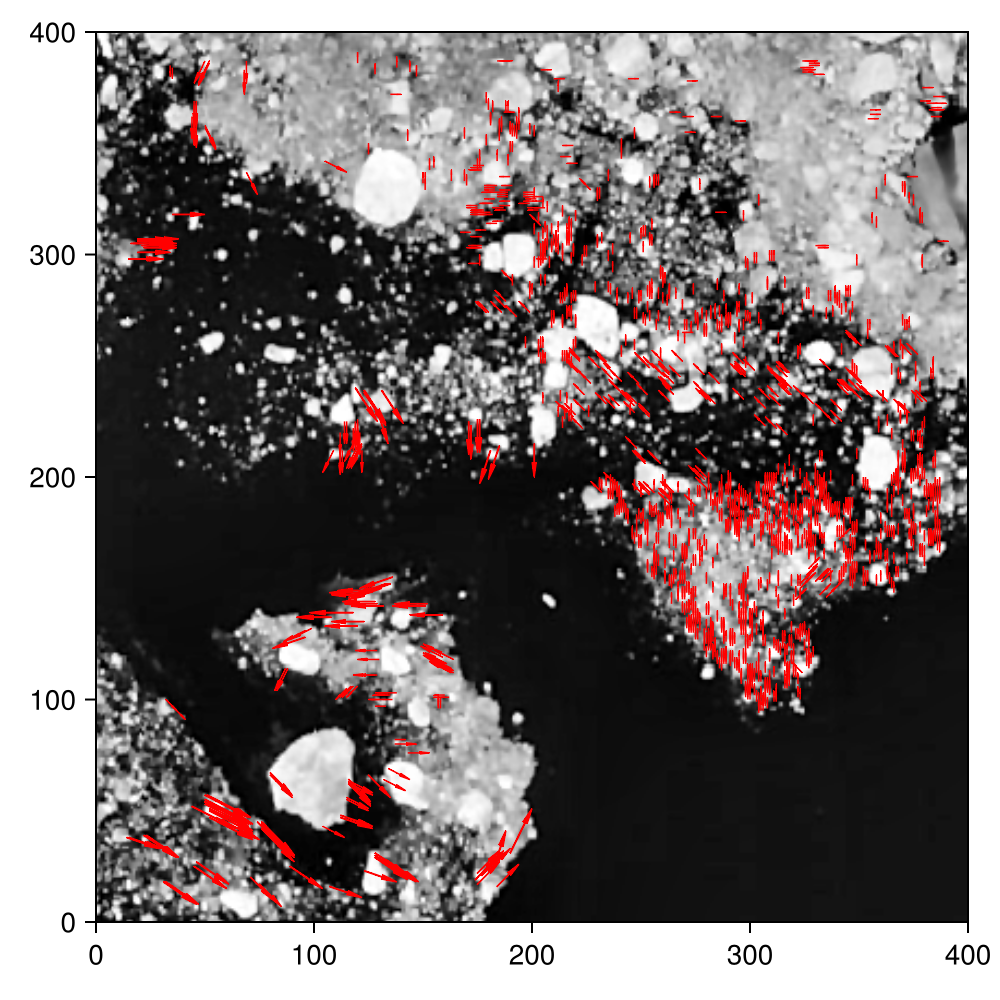

In [111]:
# Turn the cartesian indices into a vector
m1 = first.(matches) .|> r -> r.I
m2 = last.(matches) .|> r -> r.I
x = first.(m1)
y = last.(m1)
u = first.(m2) .- first.(m1)
v = last.(m2) .- last.(m1);
idx = (sqrt.(u .^ 2 .+ v .^ 2) .< 15);

f = Figure(size=(500,500))
ax = CairoMakie.Axis(f[1,1])
image!(ax, img1)
arrows2d!(x[idx], y[idx],
    u[idx], v[idx], color=:red, shaftwidth=1, tipwidth=3, lengthscale=5)
f

# ORB

Ice drift tracking at the Nansen Center uses ORB for a first set of vectors, then uses cross-correlation to get gridded motion. The Julia implementation of ORB has arguments for the number of keypoints, the number of pixels for corner finding (`fastcorners`), the threshold for corners, a "harris factor", and downsample, levels, and sigma parameters for building the gaussian pyramid. 


In [6]:
orb_params = ORB(num_keypoints = 10000, threshold=0.1, levels=10, sigma=1.2)

LoadError: UndefVarError: `ORB` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [134]:
?ORB

search: ORB ARGB XRGB



```julia
orb_params = ORB([num_keypoints = 500], [n_fast = 12], [threshold = 0.25], [harris_factor = 0.04], [downsample = 1.3], [levels = 8], [sigma = 1.2])
```

| Argument          | Type    | Description                                                                                               |
|:----------------- |:------- |:--------------------------------------------------------------------------------------------------------- |
| **num_keypoints** | Int     | Number of keypoints to extract and size of the descriptor calculated                                      |
| **n_fast**        | Int     | Number of consecutive pixels used for finding corners with FAST. See [`fastcorners`]                      |
| **threshold**     | Float64 | Threshold used to find corners in FAST. See [`fastcorners`]                                               |
| **harris_factor** | Float64 | Harris factor `k` used to rank keypoints by harris responses and extract the best ones                    |
| **downsample**    | Float64 | Downsampling parameter used while building the gaussian pyramid. See [`gaussian_pyramid`] in Images.jl    |
| **levels**        | Int     | Number of levels in the gaussian pyramid.  See [`gaussian_pyramid`] in Images.jl                          |
| **sigma**         | Float64 | Used for gaussian smoothing in each level of the gaussian pyramid.  See [`gaussian_pyramid`] in Images.jl |


In [139]:
desc_1, ret_keypoints_1 = create_descriptor(img1, orb_params)
desc_2, ret_keypoints_2 = create_descriptor(img2, orb_params);

In [140]:
matches = match_keypoints(ret_keypoints_1, ret_keypoints_2, desc_1, desc_2, 0.2);

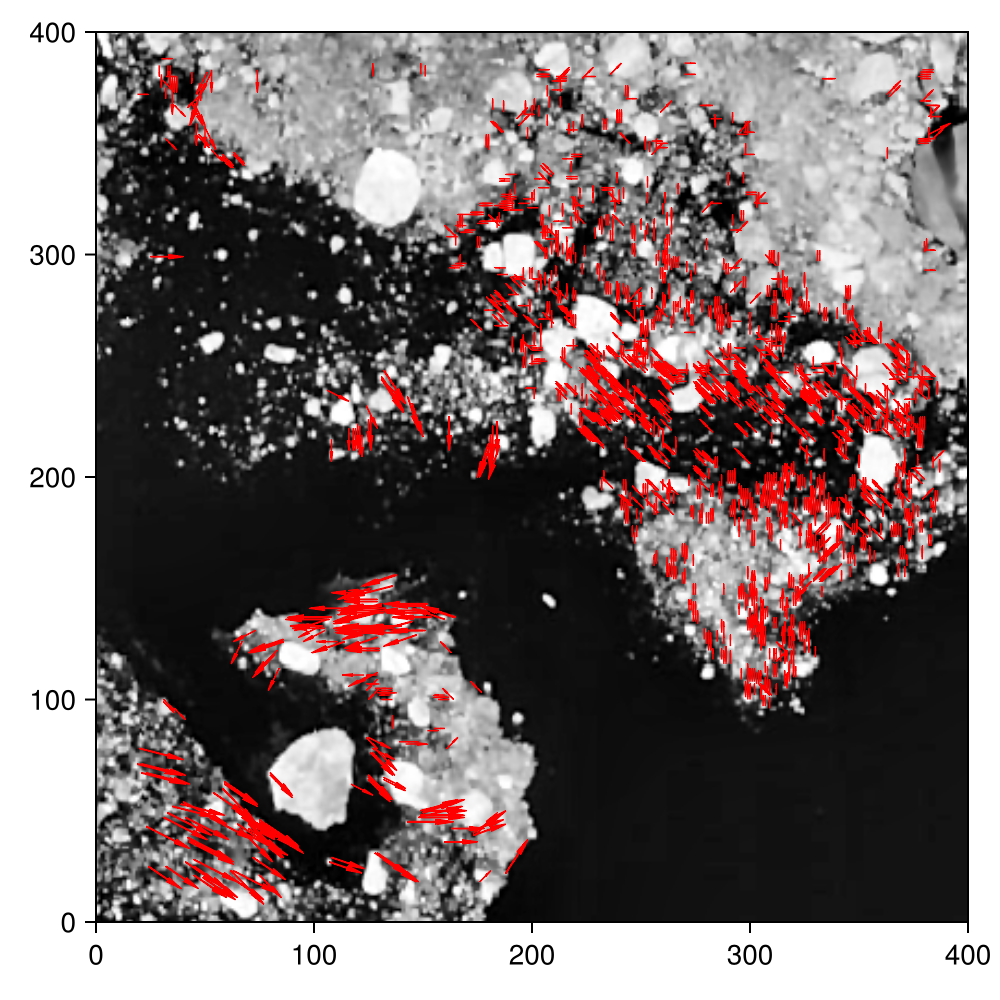

In [141]:
# Turn the cartesian indices into a vector
m1 = first.(matches) .|> r -> r.I
m2 = last.(matches) .|> r -> r.I
x = first.(m1)
y = last.(m1)
u = first.(m2) .- first.(m1)
v = last.(m2) .- last.(m1);
idx = (sqrt.(u .^ 2 .+ v .^ 2) .< 15);

f = Figure(size=(500,500))
ax = CairoMakie.Axis(f[1,1])
image!(ax, img1)
arrows2d!(x[idx], y[idx],
    u[idx], v[idx], color=:red, shaftwidth=1, tipwidth=3, lengthscale=5)
f